### **Problem Statement: Fashion MNIST is a dataset comprising 60,000 training images and 10,000 testing images, each depicting various fashion items in a 28x28 grayscale format. The dataset encompasses ten distinct categories of apparel. The primary aim of this assignment is to develop a fully connected neural network (FCNN) that can accurately classify these images into the correct fashion categories.**

In [ ]:
#importing fashion mnist dataset

import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
# now you have x_train, y_train, x_test, y_test available
# to use in your code.


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# checking the shape of dataset
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape )

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [ ]:
#print the first 10 values from y_train

print(y_train[:10])


[9 0 0 3 0 2 7 2 5 5]


In [ ]:
#print the first 10 values from x_train

print(x_train[:10])


[[[  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  ...
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]]

 [[  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  ...
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]]

 [[  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  ...
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]]

 ...

 [[  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  ...
  [  0   0   0 ... 180   0   0]
  [  0   0   0 ...  72   0   0]
  [  0   0   0 ...  70   0   0]]

 [[  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...  39   1   0]
  ...
  [  0   0   0 ... 238   0   0]
  [  0   0   0 ... 131   0   0]
  [  0   0   0 ...   0   0  

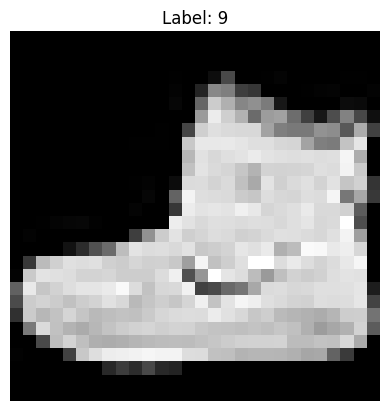

In [ ]:
#Visualizing the the data.
import matplotlib.pyplot as plt
plt.imshow(x_train[0], cmap='gray')  # Show the first image
plt.title(f"Label: {y_train[0]}")
plt.axis('off')  # Hide axes
plt.show()

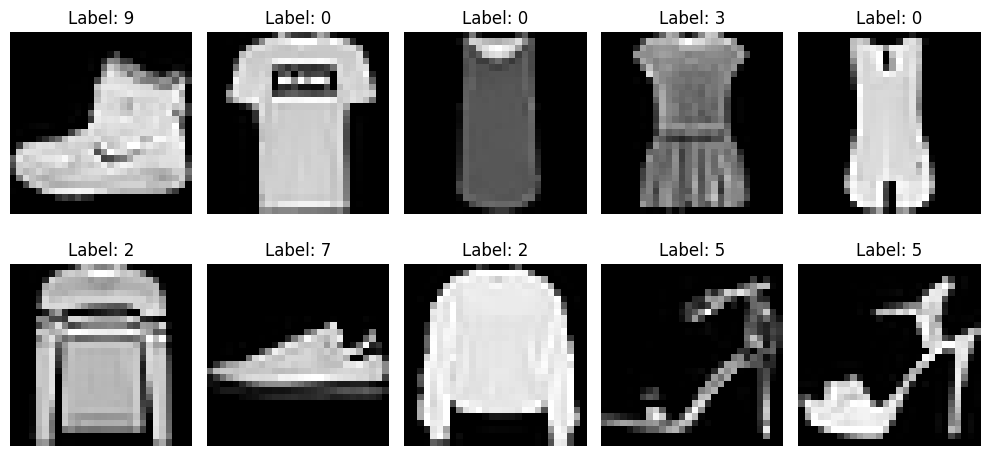

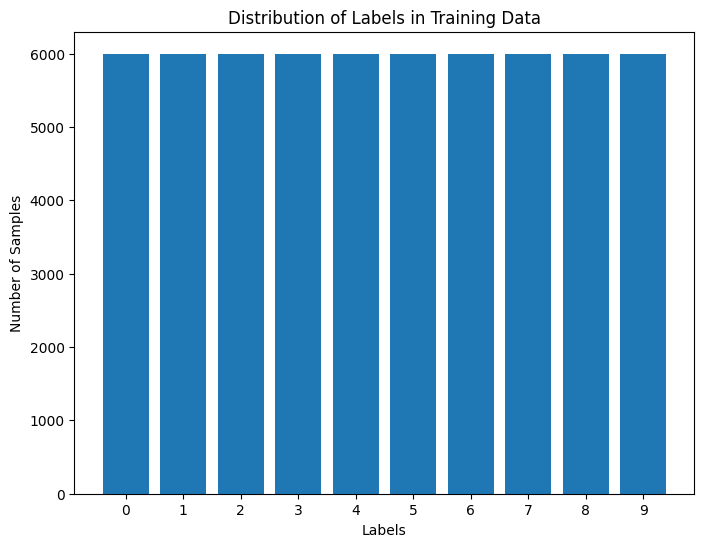

In [ ]:
#display the training data x_train distribution in the label y_train through data visualization

import numpy as np

# Assuming x_train and y_train are already loaded as in your previous code

# Create a figure and axes for the subplots
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 5))
axes = axes.flatten()  # Flatten the axes array for easier iteration

# Iterate through the first 10 images and their corresponding labels
for i in range(10):
    ax = axes[i]  # Get the current subplot
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

# Distribution of labels
label_counts = np.bincount(y_train)  # Count occurrences of each label

plt.figure(figsize=(8, 6))
plt.bar(np.arange(len(label_counts)), label_counts)
plt.xlabel("Labels")
plt.ylabel("Number of Samples")
plt.title("Distribution of Labels in Training Data")
plt.xticks(np.arange(len(label_counts)))
plt.show()


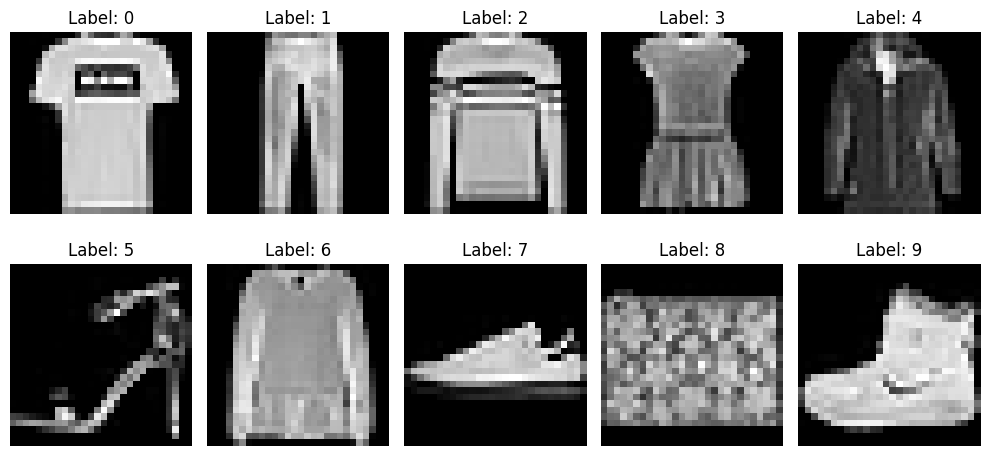

In [ ]:
# Checking all the unique label with visualization.
# Load dataset
#(x_train, y_train), _ = tf.keras.datasets.fashion_mnist.load_data()

# Dictionary to store one image per label
unique_images = {}

# Iterate through the dataset and collect the first image for each label
for i, label in enumerate(y_train):
    if label not in unique_images:
        unique_images[label] = x_train[i]  # Store the first occurrence of the label

    if len(unique_images) == 10:  # Stop once all 10 labels are found
        break

# Sort the images by label order (0-9)
sorted_labels = sorted(unique_images.keys())
sorted_images = [unique_images[label] for label in sorted_labels]

# Create a figure with subplots for 10 images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.flatten()

# Plot each unique label's image
for ax, img, label in zip(axes, sorted_images, sorted_labels):
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# normalizing the image pixel value for efficient model training

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0


In [ ]:
#Converting the categorical labels into a one-hot encoded format to suit the neural network’s output layer.
from sklearn.preprocessing import OneHotEncoder

# Initialize OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Apply OHE to both y_train and y_test
y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_encoded = encoder.transform(y_test.reshape(-1, 1))  # Use transform, not fit_transform

print(y_train_encoded.shape, y_test_encoded.shape)


(60000, 10) (10000, 10)


In [ ]:
#displaying the array.

print(x_train)
print(y_train)
print(x_test)
print(y_test)
print(y_train_encoded)
y_test_encoded


[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]
[9 0 0 ...

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

### **Builiding the Model with different hyperparameter tuning to get maximum accuarcy and avoid under fitting and overfitting.**

In [ ]:
#Design a fully connected neural network with appropriate input, hidden and output layers.

# Define the model
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),  # Input layer (flattens 28x28 images)
  tf.keras.layers.Dense(128, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)), # Hidden layer with 128 neurons and ReLU activation
  tf.keras.layers.Dense(64, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)), # Hidden layer with 64 neurons and ReLU activation
  tf.keras.layers.Dense(32, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)), # Hidden layer with 32 neurons and Relu Activation
  tf.keras.layers.Dropout(0.2),


  tf.keras.layers.Dense(10, activation='softmax')  # Output layer with 10 neurons (for 10 classes) and softmax activation
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',  # Use categorical crossentropy for one-hot encoded labels
              metrics=['accuracy'])

# Train the model
history = model.fit(x_train, y_train_encoded, epochs=30, validation_split = 0.2, batch_size=32) # Adjust epochs as needed

# Evaluate the model
loss, accuracy = model.evaluate(x_test, y_test_encoded)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7122 - loss: 1.0722 - val_accuracy: 0.8409 - val_loss: 0.6088
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8339 - loss: 0.6367 - val_accuracy: 0.8509 - val_loss: 0.5460
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8434 - loss: 0.5746 - val_accuracy: 0.8347 - val_loss: 0.5621
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8514 - loss: 0.5472 - val_accuracy: 0.8567 - val_loss: 0.5144
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8544 - loss: 0.5264 - val_accuracy: 0.8550 - val_loss: 0.5022
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8601 - loss: 0.5016 - val_accuracy: 0.8583 - val_loss: 0.5090
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8660 - loss: 0.4847 - val_accuracy: 0.8489 - val_loss: 0.5069
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8652 - loss: 0.4813

In [ ]:
# With SGD Optimizer
# Define the model
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
  tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
  tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10, activation='softmax')
])

# Compile the model with a custom learning rate
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(x_train, y_train_encoded, epochs=30, validation_split=0.2, batch_size=32)

# Evaluate the model
loss, accuracy = model.evaluate(x_test, y_test_encoded)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5583 - loss: 1.6615 - val_accuracy: 0.7814 - val_loss: 0.9348
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7808 - loss: 0.9798 - val_accuracy: 0.8234 - val_loss: 0.8391
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8150 - loss: 0.8739 - val_accuracy: 0.8387 - val_loss: 0.7847
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8233 - loss: 0.8282 - val_accuracy: 0.8494 - val_loss: 0.7431
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8377 - loss: 0.7816 - val_accuracy: 0.8550 - val_loss: 0.7131
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8394 - loss: 0.7590 - val_accuracy: 0.8570 - val_loss: 0.6877
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8438 - loss: 0.7298 - val_accuracy: 0.8570 - val_loss: 0.6817
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8515 - loss: 0.7028 

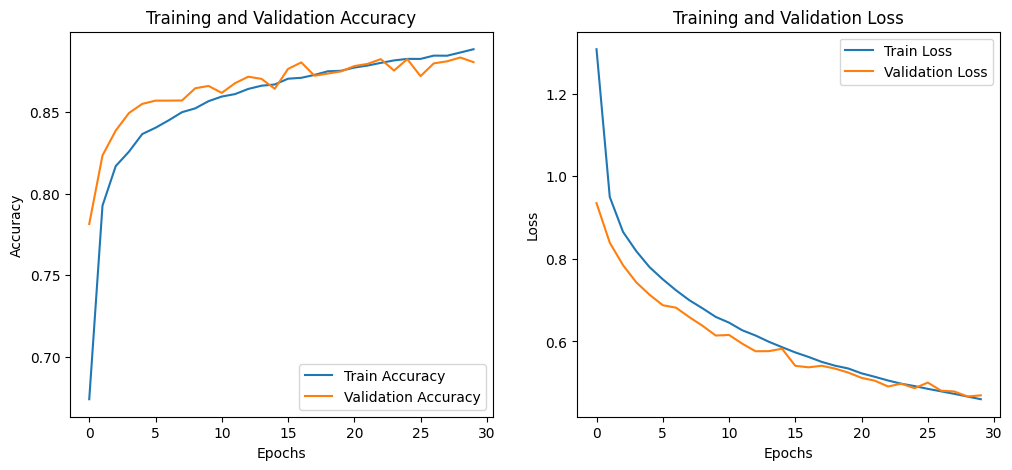

In [ ]:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.show()

In [ ]:
# Withdropout
# prompt: Design a fully connected neural network with appropriate input, hidden and output layers.

# Define the model
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),  # Input layer (flattens 28x28 images)
  tf.keras.layers.Dense(128, activation='relu'),  # Hidden layer with 128 neurons and ReLU activation
  tf.keras.layers.Dropout(0.1),
  tf.keras.layers.Dense(10, activation='softmax')  # Output layer with 10 neurons (for 10 classes) and softmax activation
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',  # Use categorical crossentropy for one-hot encoded labels
              metrics=['accuracy'])

# Train the model

history = model.fit(x_train, y_train_encoded, epochs=40, validation_split = 0.2) # Adjust epochs as needed

# Evaluate the model
loss, accuracy = model.evaluate(x_test, y_test_encoded)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Epoch 1/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7627 - loss: 0.6807 - val_accuracy: 0.8553 - val_loss: 0.4106
Epoch 2/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8557 - loss: 0.3959 - val_accuracy: 0.8503 - val_loss: 0.4046
Epoch 3/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8699 - loss: 0.3529 - val_accuracy: 0.8731 - val_loss: 0.3545
Epoch 4/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8767 - loss: 0.3368 - val_accuracy: 0.8746 - val_loss: 0.3589
Epoch 5/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8836 - loss: 0.3174 - val_accuracy: 0.8820 - val_loss: 0.3315
Epoch 6/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8914 - loss: 0.2977 - val_accuracy: 0.8707 - val_loss: 0.3609
Epoch 7/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8893 - loss: 0.2928 - val_accuracy: 0.8793 - val_loss: 0.3333
Epoch 8/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8928 - loss: 0.2820 

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape for CNN (adding channel dimension)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# One-Hot Encoding of labels
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Define model
model = Sequential([
    Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.2),  # Regularization

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')  # 10 classes
])

# Hyperparameters tuning
learning_rate = 0.001  # Try 0.0005 if needed
optimizer = Adam(learning_rate=learning_rate)

# Compile model
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks for tuning
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),  # Reduce LR if no improvement
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)  # Stop early to prevent overfitting
]

# Train model
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=20, batch_size=64, callbacks=callbacks)

# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 141s 148ms/step - accuracy: 0.7186 - loss: 0.7716 - val_accuracy: 0.8609 - val_loss: 0.3748 - learning_rate: 0.0010
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 143s 150ms/step - accuracy: 0.8613 - loss: 0.3824 - val_accuracy: 0.8782 - val_loss: 0.3322 - learning_rate: 0.0010
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 143s 151ms/step - accuracy: 0.8787 - loss: 0.3291 - val_accuracy: 0.8828 - val_loss: 0.3169 - learning_rate: 0.0010
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 135s 143ms/step - accuracy: 0.8900 - loss: 0.2964 - val_accuracy: 0.9013 - val_loss: 0.2673 - learning_rate: 0.0010
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 135s 144ms/step - accuracy: 0.8958 - loss: 0.2805 - val_accuracy: 0.9052 - val_loss: 0.2565 - learning_rate: 0.0010
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 142s 144ms/step - accuracy: 0.9044 - loss: 0.2578 - val_accuracy: 0.9039 - val_loss: 0.2614 - learning_rate: 0.0010
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 142s 144ms/step - accura

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 142s 150ms/step - accuracy: 0.6198 - loss: 1.0134 - val_accuracy: 0.8151 - val_loss: 0.4924 - learning_rate: 0.0100
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 136s 143ms/step - accuracy: 0.8074 - loss: 0.5137 - val_accuracy: 0.8506 - val_loss: 0.4143 - learning_rate: 0.0100
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 147s 149ms/step - accuracy: 0.8388 - loss: 0.4362 - val_accuracy: 0.8514 - val_loss: 0.3881 - learning_rate: 0.0100
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 136s 143ms/step - accuracy: 0.8589 - loss: 0.3851 - val_accuracy: 0.8764 - val_loss: 0.3363 - learning_rate: 0.0100
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 135s 144ms/step - accuracy: 0.8698 - loss: 0.3582 - val_accuracy: 0.8870 - val_loss: 0.3101 - learning_rate: 0.0100
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 146s 148ms/step - accuracy: 0.8785 - loss: 0.3345 - val_accuracy: 0.8918 - val_loss: 0.2991 - learning_rate: 0.0100
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 134s 143ms/step - accura

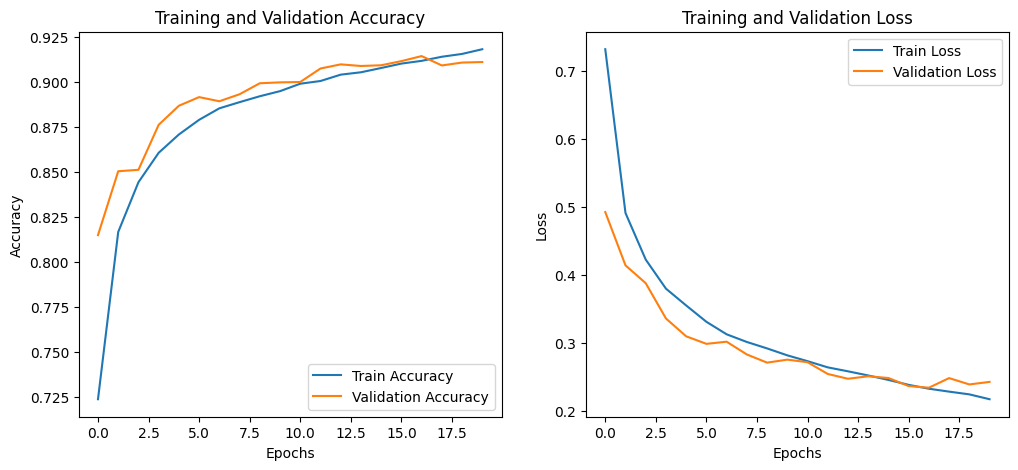

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import numpy as np

# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape for CNN (adding channel dimension)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# One-Hot Encoding of labels
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Define model
model = Sequential([
    Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')  # 10 classes
])

# **SGD Optimizer with Momentum**
learning_rate = 0.01  # Try reducing to 0.005 if needed
momentum = 0.9
optimizer = SGD(learning_rate=learning_rate, momentum=momentum, nesterov=True)

# Compile model
history = model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

# Train model
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=20, batch_size=64, callbacks=callbacks)

# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

    # Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

# Define the model
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),  # Input layer (flattens 28x28 images)
  tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)), # Hidden layer with 128 neurons and ReLU activation
  tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)), # Hidden layer with 64 neurons and ReLU activation
  tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)), # Hidden layer with 32 neurons and Relu Activation
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10, activation='softmax')  # Output layer with 10 neurons (for 10 classes) and softmax activation
])

# Compile the model with increased learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',  # Use categorical crossentropy for one-hot encoded labels
              metrics=['accuracy'])

# Train the model and store the history
history = model.fit(x_train, y_train_encoded, epochs=30, validation_split=0.2, batch_size=32)  # Added batch_size=32

# Ensure history is defined before using it
if history:
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.show()
